# PCA — fewer columns, without throwing any away

## The story

Ritu runs the screening desk at a clinic. Every patient who walks in leaves
eight numbers behind: pregnancies, glucose, blood pressure, skin thickness,
insulin, BMI, a family-history score, and age. She trained an `SVC` to read
those eight numbers and flag who should come back for a proper blood test, and
it scored **79%** on patients it had never seen.

Then she was told the panel is going to grow. More instruments, more columns,
and an `SVC` that already takes a while on 768 rows. Before the table got wider
she wanted to know something simpler: **how many columns' worth of information
is actually in there?** Eight columns describing one patient are not eight
independent facts — skin thickness and BMI are measuring related things, and so
are age and pregnancies.

So she did the obvious thing: drop the columns that look least useful. Insulin
is blank for nearly half the rows anyway — drop it. Skin thickness looks like a
rough stand-in for BMI — drop that too. The score fell, and kept falling as she
dropped more. Nothing in the panel was redundant *enough* to delete. Each column
carried a small, partly-overlapping piece of the signal, and deleting a column
deleted its piece.

**The mistake is in the word "drop".** She was choosing between the eight columns
she was handed. Those eight are not the only way to describe a patient. PCA
builds **new** columns — each one a blend of all eight — ordered so the first few
carry most of what spread the patients apart to begin with. Keep six of those and
nothing is thrown away: the overlap is folded together, not deleted.

One thing to be clear about before the code, because the story invites the wrong
conclusion: **PCA does not save Ritu a blood test.** Every component is a mix of
all eight measurements, so she still has to measure all eight to compute one.
What gets narrower is the table the model sees, not the form at the desk.

## What PCA actually does

One sentence: **PCA finds the directions along which the rows are most spread
out, and uses those directions as the new axes.**

- The first component is the direction of largest spread in the data.
- The second is the direction of largest *remaining* spread, at right angles to
  the first. And so on.
- Each component is a weighted mix of all the original columns, so every column
  still has a say.
- Spread is measured as **variance**, and each component reports how much of
  the total it captured — `explained_variance_ratio_`.

Two things follow, and both matter in the code below:

1. **It never looks at `y`.** PCA is unsupervised. It maximises spread, not
   separation between classes. (That is exactly where
   [LDA](../../36_Linear_Discriminant_Analysis/Concept/34_LDA_explained.ipynb)
   differs — LDA uses the labels.)
2. **Scale first, always.** Variance has units. Insulin runs to 846 and the
   family-history score sits under 2.5, so on raw numbers insulin *is* the
   first component, for no reason other than the unit it was recorded in.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score

KEEP, CUT, LINE = "#1f7a8c", "#e4572e", "#888888"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})

df = pd.read_csv("../Data/pca1.csv")
x = df[["A", "B", "C", "D", "E", "F", "G", "H"]]
y = df["I"]

PANEL = ["pregnancies", "glucose", "blood pressure", "skin thickness",
         "insulin", "BMI", "family history", "age"]
print(f"{len(df)} patients, {x.shape[1]} measurements")
print(f"follow-up needed : {y.sum()}   not needed : {(y == 0).sum()}")
x.describe().loc[["min", "max", "std"]].round(1)

768 patients, 8 measurements
follow-up needed : 268   not needed : 500


,A,B,C,D,E,F,G,H
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8


Read the `std` row. Insulin varies by 115, the family-history score by 0.33.
Variance is what PCA maximises, so on these raw numbers insulin would own the
first component — not because it tells us more, but because it is written in
bigger units. `StandardScaler` puts every column on the same footing first.

In [2]:
data_scaler   = StandardScaler().fit(x)
data_rescaled = data_scaler.transform(x)

pca_all = PCA().fit(data_rescaled)          # no n_components: keep all eight
ratio   = pca_all.explained_variance_ratio_
cum     = ratio.cumsum()

for i, (r, c) in enumerate(zip(ratio, cum), start=1):
    print(f"component {i}:  holds {r:5.1%} of the spread   running total {c:5.1%}")

component 1:  holds 26.2% of the spread   running total 26.2%
component 2:  holds 21.6% of the spread   running total 47.8%
component 3:  holds 12.9% of the spread   running total 60.7%
component 4:  holds 10.9% of the spread   running total 71.6%
component 5:  holds  9.5% of the spread   running total 81.2%
component 6:  holds  8.5% of the spread   running total 89.7%
component 7:  holds  5.2% of the spread   running total 94.9%
component 8:  holds  5.1% of the spread   running total 100.0%


That running total is the whole decision. The first component alone holds a
quarter of the spread; the last one holds almost nothing. The plot below is the
same numbers, which is how you actually read them.

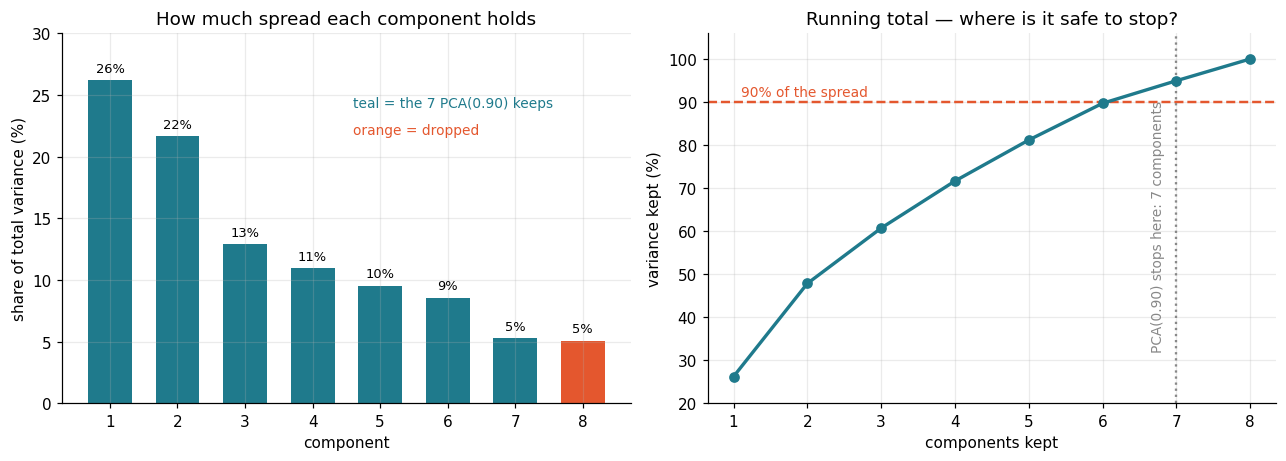

In [3]:
k = np.arange(1, len(ratio) + 1)
n90 = int(np.searchsorted(cum, 0.90) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.3))

colours = [KEEP if i < n90 else CUT for i in range(len(ratio))]
bars = ax1.bar(k, ratio * 100, color=colours, width=.65)
for b, r in zip(bars, ratio):
    ax1.text(b.get_x() + b.get_width() / 2, r * 100 + .7, f"{r:.0%}",
             ha="center", fontsize=8.5)
ax1.set(title="How much spread each component holds",
        xlabel="component", ylabel="share of total variance (%)", ylim=(0, 30))
ax1.text(4.6, 24, f"teal = the {n90} PCA(0.90) keeps", color=KEEP, fontsize=9)
ax1.text(4.6, 21.8, "orange = dropped", color=CUT, fontsize=9)

ax2.plot(k, cum * 100, marker="o", c=KEEP, lw=2.2, zorder=3)
ax2.axhline(90, c=CUT, ls="--", lw=1.6)
ax2.text(1.1, 91.5, "90% of the spread", color=CUT, fontsize=9)
ax2.axvline(n90, c=LINE, ls=":", lw=1.5)
ax2.text(n90 - .15, 32, f"PCA(0.90) stops here: {n90} components",
         color=LINE, fontsize=9, rotation=90, va="bottom", ha="right")
ax2.set(title="Running total — where is it safe to stop?",
        xlabel="components kept", ylabel="variance kept (%)", ylim=(20, 106))

plt.tight_layout(); plt.show()

The left panel is the **scree plot**, and it has no cliff. That is the honest
reading of this dataset: the eight measurements are not eight copies of two
ideas, so no small number of components captures everything. The last two
components still hold about 5% each — small, but not zero.

The right panel is the one you act on. Asking for 90% of the spread lands on
seven components, which is what the class notebook got:

```python
pca  = PCA(0.90)              # a float < 1 means "keep enough components for this much variance"
xpca = pca.fit_transform(data_rescaled)
xpca.shape                    # (768, 7)
```

A float asks for *variance*; an integer asks for a *count*:

```python
pca = PCA(n_components=6)     # "give me exactly six, whatever they hold"
```

## What a component is made of

A component is not one of the original columns and it is not a subset of them.
It is a recipe. `pca.components_` holds the weights.

In [4]:
pca6 = PCA(n_components=6).fit(data_rescaled)
recipe = pd.DataFrame(pca6.components_[:2].T, index=PANEL,
                      columns=["component 1", "component 2"]).round(2)
recipe

,component 1,component 2
pregnancies,0.13,0.59
glucose,0.39,0.17
blood pressure,0.36,0.18
skin thickness,0.44,-0.33
insulin,0.44,-0.25
BMI,0.45,-0.10
family history,0.27,-0.12
age,0.20,0.62


Every measurement appears in both, with a weight — that is what makes a
component a blend rather than a choice.

Component 1 loads on the body and blood measurements together: BMI 0.45, skin
thickness 0.44, insulin 0.44, glucose 0.39. Component 2 is almost entirely age
0.62 and pregnancies 0.59, and it pushes *against* skin thickness and insulin,
which is how it stays at right angles to the first.

Read the second one as "how far through life this patient is" and the first as
"how heavy the metabolic readings are" — but only loosely. A component has no
official meaning, and that is the price PCA charges.

Nothing was deleted here. The eight columns were folded into six. That is the
difference between PCA and feature *selection*, which really does drop columns.

## Does the model survive the fold?

The class notebook trained the same `SVC` three times. Here is the same
comparison across every possible number of components, so the three numbers sit
in context.

One change: the scaler and the PCA go **inside a `Pipeline`**, and the score
comes from cross-validation. The class notebook scaled and ran PCA on all 768
rows and split afterwards, which lets the test rows influence the mean, the
standard deviation and the component directions they are later judged on. It is
a small leak on this dataset, and a habit worth not forming.

In [5]:
def cv_score(n_components=None):
    steps = [("scale", StandardScaler())]
    if n_components is not None:
        steps.append(("pca", PCA(n_components=n_components, random_state=0)))
    steps.append(("svc", SVC()))
    return cross_val_score(Pipeline(steps), x, y, cv=5).mean()

baseline = cv_score(None)
scores   = [cv_score(n) for n in k]

print(f"all 8 columns, no PCA : {baseline:.3f}")
for n, s in zip(k, scores):
    print(f"{n} component{'s' if n > 1 else ' '}           : {s:.3f}"
          f"   {'<- PCA(0.90) picks this' if n == n90 else ''}")

all 8 columns, no PCA : 0.772
1 component            : 0.719   
2 components           : 0.724   
3 components           : 0.737   
4 components           : 0.727   
5 components           : 0.738   
6 components           : 0.770   
7 components           : 0.773   <- PCA(0.90) picks this
8 components           : 0.772   


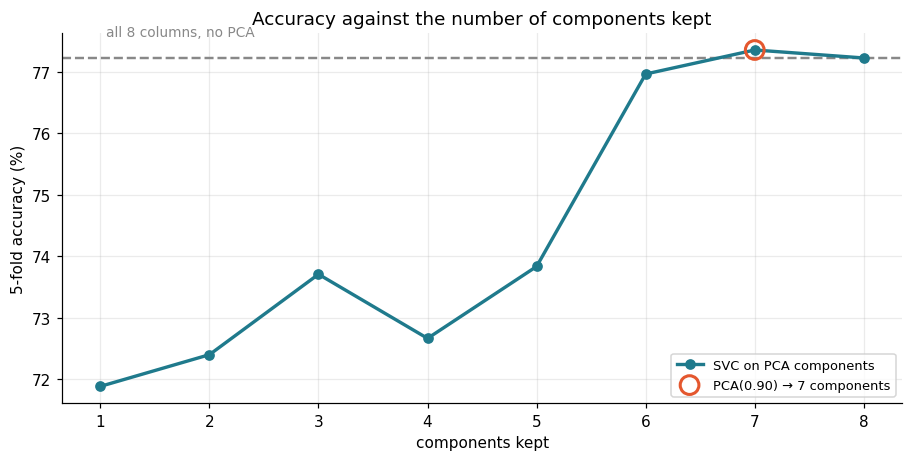

best here: 7 components at 0.773, against 0.772 on the full panel


In [6]:
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.axhline(baseline * 100, c=LINE, ls="--", lw=1.6)
ax.text(1.05, baseline * 100 + .35, "all 8 columns, no PCA", color=LINE, fontsize=9)
ax.plot(k, np.array(scores) * 100, marker="o", c=KEEP, lw=2.2, label="SVC on PCA components")
ax.scatter([n90], [scores[n90 - 1] * 100], s=150, facecolor="none",
           edgecolor=CUT, lw=2, zorder=5, label=f"PCA(0.90) → {n90} components")
ax.set(title="Accuracy against the number of components kept",
       xlabel="components kept", ylabel="5-fold accuracy (%)")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

best = int(np.argmax(scores)) + 1
print(f"best here: {best} components at {scores[best - 1]:.3f}, "
      f"against {baseline:.3f} on the full panel")

This is worth reading carefully, because it is not the tidy result PCA demos
usually show.

Up to five components the line sits **below** the full panel — those components
hold plenty of variance, but not enough of the variance that separates the two
classes. The jump happens at six (0.770), and seven (0.773) matches the full
eight columns (0.772). In other words: on this dataset PCA buys a reduction from
**eight columns to six or seven**, and not a single component less.

That is the same thing the scree plot said. No cliff, no compression. And it is
exactly what the class notebook found on its single split — 0.792 on all eight,
0.779 on seven, 0.799 on six. Those three numbers bounce around by a couple of
points because one 154-row test set is small; the shape of the curve above is
the reliable version of the same story.

So Ritu's answer is a modest one: the eight measurements really do carry about
six columns' worth of distinct information, and she can hand the model six
instead of eight. When a table has 300 columns that are genuinely repetitive,
the same plot bends sharply and you keep 20 — the method is the same, the payoff
depends entirely on how much overlap was there.

Note what the low end means. Components 1 and 2 hold 48% of all the spread and
score worse than the full panel. PCA never saw `y`, so it had no way to know
which directions of spread were the useful ones. That is its one structural
blind spot, and it is precisely what
[LDA](../../36_Linear_Discriminant_Analysis/Concept/34_LDA_explained.ipynb)
fixes by using the labels.

## Reading it back

PCA is reversible, approximately. `inverse_transform` puts the rows back into
the original eight columns, and what comes back is the data with the discarded
components removed — a useful way to see how much was actually given up.

In [7]:
xpca6 = pca6.transform(data_rescaled)
back  = pca6.inverse_transform(xpca6)

err = pd.DataFrame({
    "column": PANEL,
    "mean absolute difference (in sd units)": np.abs(data_rescaled - back).mean(axis=0).round(3),
}).set_index("column")
print(f"variance kept by 6 components: {pca6.explained_variance_ratio_.sum():.1%}")
err

variance kept by 6 components: 89.7%


,mean absolute difference (in sd units)
column,
pregnancies,0.282
glucose,0.220
blood pressure,0.091
skin thickness,0.304
insulin,0.272
BMI,0.166
family history,0.041
age,0.349


Every column comes back within about a third of a standard deviation, and the
two that suffer most — age 0.35 and skin thickness 0.30 — are the ones the
dropped components were describing. That is what "folded together, not deleted"
looks like numerically: 89.7% of the spread kept, and the 10% that went missing
is spread thinly across all eight columns rather than removing any one of them.

## Where this matters outside the clinic

The cost PCA removes is width, not accuracy. An `SVC` works through pairwise
distances, so its training time grows with rows *and* columns; a 300-column table
cut to 30 components trains far faster and the serving payload shrinks with it.
The fitted `PCA` object then becomes part of the deployed artifact, exactly like
the scaler — the same transform has to run at prediction time, or the model is
being fed numbers that mean something else. Fit both inside one `Pipeline`,
`pickle` the pipeline, ship one file.

## Common mistakes

1. **Running PCA before scaling.** The column with the biggest unit becomes
   component 1, and the rest is noise around it.
2. **Fitting on all the rows, then splitting.** The component directions were
   computed using the test rows, so the test score is flattering.
3. **Expecting a component to mean something.** It is a weighted blend with no
   name, and it cannot be explained to an auditor.
4. **Expecting PCA to reduce what you measure.** Every component needs every
   original column. It narrows the model's input, not the data collection.
5. **Reaching for PCA when the real problem is useless columns.** PCA keeps them
   all, weighted. To remove a column, use feature selection.

## Key takeaway

If you remember only one thing: **PCA does not choose between your columns, it
replaces them with a shorter set of blends ordered by how much spread they
carry** — so scale first, read the count off the cumulative-variance curve, and
fit it inside the pipeline with everything else.